In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pymoo.indicators.hv import Hypervolume
import score.envs as envs
import itertools

2024-10-18 15:10:40.654362: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-18 15:10:40.671496: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-18 15:10:40.676750: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-18 15:10:40.689760: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-18 15:10:41.680888: W tensorflow/compiler/tf2

In [2]:
env_ids = ["SCORE-MO-CEBAF-8D-VEC-TF", 
        "SCORE-MO-CEBAF-16D-VEC-TF",
        "SCORE-MO-CEBAF-32D-VEC-TF",
        "SCORE-MO-CEBAF-N-VEC-TF-v0"]

envs = [envs.make(env_id) for env_id in env_ids]
refs = [[env.linac.max_allowed_heat, env.linac.max_allowed_trip] for env in envs]

ideals = [[20.9, 0.015],
          [88., 0.015],
          [262., 0.010],
          [2380.0, 1.0]]

energy_bounds = [[env.min_energy, env.max_energy] for env in envs]

Attempting to load score.envs with mo_cebaf_env
####################################
Using action mode:  direct
####################################


2024-10-18 15:10:43.203598: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 723 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:2d:00.0, compute capability: 7.5
2024-10-18 15:10:43.205630: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13662 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:30:00.0, compute capability: 7.5


Env Name:  1l10_test8
Cavity Ids:  ['1L10-1' '1L10-2' '1L10-3' '1L10-4' '1L10-5' '1L10-6' '1L10-7' '1L10-8']
Lengths:  tf.Tensor([0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5], shape=(8,), dtype=float32)
types:  ['C25' 'C25' 'C25' 'C25' 'C25' 'C25' 'C25' 'C25']
max_gset_to_use:  [5.75 9.   9.2  6.   4.   7.6  6.6  8.2 ]
min grad:  tf.Tensor([3. 3. 3. 3. 3. 3. 3. 3.], shape=(8,), dtype=float32)
Q0s:  tf.Tensor([5.21e+09 5.00e+09 6.82e+09 4.77e+09 5.31e+09 5.32e+09 2.60e+09 3.92e+09], shape=(8,), dtype=float32)
Trip slopes:  tf.Tensor([1.301 1.485 1.942 1.911 0.487 1.519 2.788 1.339], shape=(8,), dtype=float32)
Trip Offset:  tf.Tensor([9.328 8.724 8.845 5.679 9.528 8.108 6.389 7.684], shape=(8,), dtype=float32)
Initial gradients:  tf.Tensor([[5.75 9.   9.2  6.   4.   7.6  6.6  8.2 ]], shape=(1, 8), dtype=float32)
Requred energy mean:  20.08   with allowed margin:  0.4
Using min, max energy boundaries as:  tf.Tensor(12.0, shape=(), dtype=float32) tf.Tensor(28.175, shape=(), dtype=float32)
Min and Max 

In [3]:
envs[0].linac.max_allowed_trip

0.04

In [4]:
def calculate_hv(heat, trip, ref, ideal):
    metric = Hypervolume(ref_point= ref,
                         norm_ref_point=False,
                         zero_to_one=False,
                         ideal=ideal,
                         nadir=ref)
    max_vol = (ref[0] - ideal[0]) * (ref[1] - ideal[1])
    good_indices = np.where((heat <= ref[0]) & (trip <= ref[1]))[0]
    
    # If no points are below reference, return hypervolume as 0.
    if good_indices.shape[0] <= 0:
        return 0.
    heat, trip = heat[good_indices], trip[good_indices]
    results = np.stack([heat, trip], axis=1)
    
    return np.round(metric.do(results)*100/max_vol, 3)

In [5]:
def read_results(path, energy_min, energy_max, ref, ideal):
    heat, trip, time, step_time = [], [], [], []
    hv_list = []
    files = sorted(os.listdir(path))
    for file in files:
        
        if file[-4:] != ".pkl":
            continue
        
        result_dict = np.load(os.path.join(path, file), allow_pickle=True)
        h = np.array(result_dict["heat"])
        t = np.array(result_dict["trip"])
        if "MOBO" in path:
            energy = np.array(result_dict["energy"])
            good_indices = np.where((energy <= energy_max) & (energy >= energy_min))[0]
            h = h[good_indices]
            t = t[good_indices]
        heat.append(h)
        trip.append(t)
        step_time.append(result_dict["step_time"])
        time.append(result_dict["t_elapsed"])
        hv_list.append(calculate_hv(h, t, ref, ideal))
    return heat, trip, np.array(time), np.array(step_time), hv_list

In [6]:
root_dir = "/work/data_science/kishan_RL_results/"
path_list_512 = [os.path.join(root_dir, "results/MOO_paper_study_v2/MOGA/"),
            os.path.join(root_dir, "results/MOO_paper_study_16D/MOGA/"),
            os.path.join(root_dir, "results/MOO_paper_study_32D/MOGA/"),
            os.path.join(root_dir, "results/MOO_paper_study_v2/MOGA_North/")]

path_list_256 = [os.path.join(root_dir, "results/MOO_paper_study_v2/MOGA_256/"),
            os.path.join(root_dir, "results/MOO_paper_study_16D/MOGA_256/"),
            os.path.join(root_dir, "results/MOO_paper_study_32D/MOGA_256/"),
            os.path.join(root_dir, "results/MOO_paper_study_v2/MOGA_North_256/")]
path_list_128 = [os.path.join(root_dir, "results/MOO_paper_study_v2/MOGA_128/"),
            os.path.join(root_dir, "results/MOO_paper_study_16D/MOGA_128/"),
            os.path.join(root_dir, "results/MOO_paper_study_32D/MOGA_128/"),
            os.path.join(root_dir, "results/MOO_paper_study_v2/MOGA_North_128/")]
label_list = ["8D", "16D", "32D", "North linac"]
# colors = ['#F2490D', '#0DB6F2', '#75DB24', "#8A24DB"]
colors = ['#CD5232', '#32ADCD', '#8144BB']

In [7]:
def read(path, energy_bound, ref, ideal):
    
    heat_list = []
    trip_list = []
    time_list = []
    hv_list = []
    for i in range(1, 17):
        full_path = os.path.join(path, "trial_"+str(i))
        heat, trip, time, step_time, hv = read_results(full_path, energy_bound[0], energy_bound[1], ref, ideal)
        heat_list.append(heat)
        trip_list.append(trip)
        time_list.append(time)
        hv_list.append(hv)
    return heat_list, trip_list, time_list, hv_list

In [8]:
results_512 = []
for i, path in enumerate(path_list_512):
    h, t, time, hv = read(path, energy_bounds[i], refs[i], ideals[i])
    results_512.append([h, t, time, hv])
    print("Read: ", path)

Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOGA/
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_16D/MOGA/
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_32D/MOGA/
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOGA_North/


In [9]:
results_256 = []
for i, path in enumerate(path_list_256):
    h, t, time, hv = read(path, energy_bounds[i], refs[i], ideals[i])
    results_256.append([h, t, time, hv])
    print("Read: ", path)

Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOGA_256/
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_16D/MOGA_256/
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_32D/MOGA_256/
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOGA_North_256/


In [10]:
results_128 = []
for i, path in enumerate(path_list_128):
    h, t, time, hv = read(path, energy_bounds[i], refs[i], ideals[i])
    results_128.append([h, t, time, hv])
    print("Read: ", path)

Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOGA_128/
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_16D/MOGA_128/
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_32D/MOGA_128/
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOGA_North_128/


In [11]:
# np.mean(results_128[0][3], axis=0)

In [12]:
results = [results_128, results_256, results_512]

In [13]:
plt.rcParams['font.family'] = 'serif'  # or 'sans-serif', 'monospace'
# plt.rcParams['font.serif'] = ['Times New Roman']

/scratch/slurm/31353920/.cache/tmp/ipykernel_1552915/2887975051.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=18)


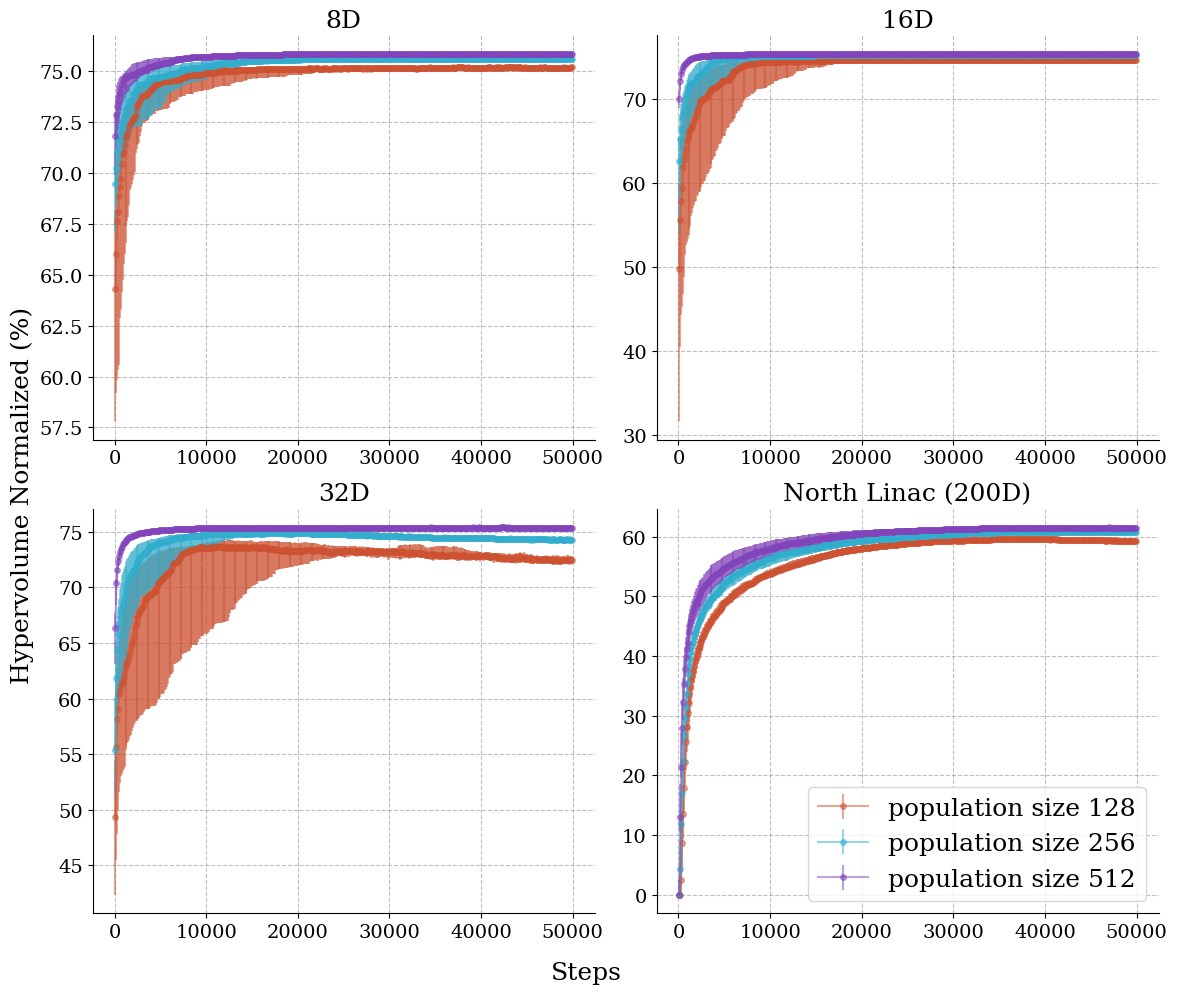

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data for four different comparisons
# x = np.linspace(100, 49900, 499)  # X values
# y1 = [np.sin(x), np.sin(x + 0.2), np.sin(x + 0.4)]                 # First trace
# y2 = [np.cos(x), np.cos(x +  0.2), np.cos(x + 0.4)]                # Second trace
# y3 = [np.sin(x + 0.5), np.sin(x + 0.1), np.sin(x + 0.8)]          # Third trace
# y4 = [np.cos(x + 0.5), np.cos(x), np.cos(x + 0.4)]       # Fourth trace





# Create a figure and a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Data for each subplot
x = np.linspace(100, 49900, 499)  # X values

# y_values = [y1, y2, y3, y4]
titles = ['8D', '16D', '32D', 'North Linac (200D)']
labels = [128, 256, 512]
counter = 0
# Iterate through subplots
q_lower = 0.1
q_higher = 0.9
for ax, title in zip(axs.ravel(), titles):
    for i, result in enumerate(results):
        if i == -1:
            continue
        mean = np.mean(result[counter][3], axis=0)
        median = np.median(result[counter][3], axis=0)
        lower = np.quantile(result[counter][3], axis=0, q=q_lower)
        higher = np.quantile(result[counter][3], axis=0, q=q_higher)
        ax.errorbar(x, median, yerr=np.stack([median-lower, higher-median]), marker='o', linestyle='-', markersize=4, alpha=0.5, color=colors[i], label="population size "+str(labels[i]))
    counter += 1

    

    # ax.plot(x, y[0], marker='o', linestyle='-', markersize=4, alpha=0.8, color=colors[0])
    # ax.plot(x, y[1], marker='o', linestyle='-', markersize=4, alpha=0.8, color=colors[1])
    # ax.plot(x, y[2], marker='o', linestyle='-', markersize=4, alpha=0.8, color=colors[2])
    
    # Customize the axes
    ax.set_title(title, fontsize=18)
    # ax.set_xlabel('Steps', fontsize=14)
    # ax.set_ylabel('Hypervolume Normalized (%)', fontsize=14)
    ax.grid(color="gray", alpha=0.5, ls="--")
    # Remove box around the plot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.legend(fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=14)
    
fig.supxlabel('Steps', fontsize=18)
fig.supylabel('Hypervolume Normalized (%)', fontsize=18)

# Adjust layout
plt.tight_layout()
plt.savefig("GA_Coverage_Comparison.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
refs[0] = [22.0, 0.04]

/scratch/slurm/31353920/.cache/tmp/ipykernel_1552915/1945266127.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=18)


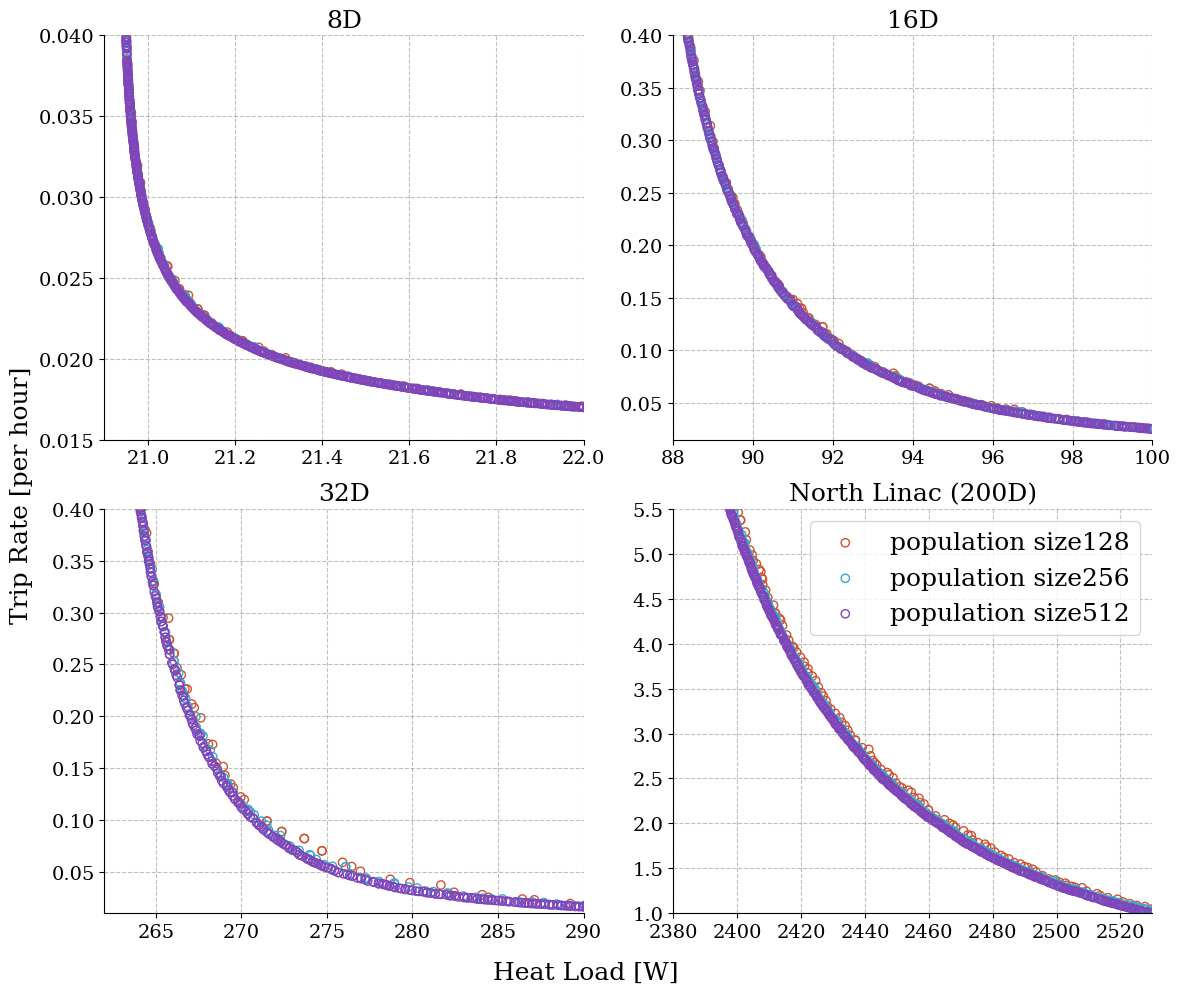

In [16]:
import numpy as np
import matplotlib.pyplot as plt


fig, axs = plt.subplots(2, 2, figsize=(12, 10))

titles = ['8D', '16D', '32D', 'North Linac (200D)']
labels = [128, 256, 512]
counter = 0
# Iterate through subplots
q_lower = 0.1
q_higher = 0.9
for ax, title in zip(axs.ravel(), titles):
    for i, result in enumerate(results):
        indx = np.where(np.array(result[counter][3])[:, -1] == np.max(np.array(result[counter][3])[:, -1]))
        # ind1, ind2 = indx[0][0], indx[1][0]
        # ind1, ind2 = 0, 498
        heat = result[counter][0][indx[0][0]][-1]
        trip = result[counter][1][indx[0][0]][-1]
        
        ax.scatter(heat, 
                   trip, 
                   edgecolor=colors[i], 
                   facecolor="none",
                   label="population size"+str(labels[i]),
                   # alpha=0.5
                  )
        ax.set_xlim([ideals[counter][0], refs[counter][0]])
        ax.set_ylim([ideals[counter][1], refs[counter][1]])
    counter += 1

    

    # Customize the axes
    ax.set_title(title, fontsize=18)
    # ax.set_xlabel('Steps', fontsize=14)
    # ax.set_ylabel('Hypervolume Normalized (%)', fontsize=14)
    ax.grid(color="gray", alpha=0.5, ls="--")
    # Remove box around the plot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.legend(fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=14)
    
fig.supxlabel('Heat Load [W]', fontsize=18)
fig.supylabel('Trip Rate [per hour]', fontsize=18)

# Adjust layout
plt.tight_layout()
plt.savefig("GA_Pareto_Comparison.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()